# Task
Perform K-Nearest Neighbors (KNN) classification on three datasets: 'iris.csv', 'diabetes.csv', and 'heart.csv'. For 'iris.csv', split data 80/20, predict scores, and display accuracy, confusion matrix, and classification report. For 'diabetes.csv', scale features, split data 80/20, predict scores, and display accuracy and confusion matrix. For 'heart.csv', optimize the k-value to find the maximum score, then plot the confusion matrix and classification report for the best model.

## Load Iris Dataset

### Subtask:
Load the 'iris.csv' dataset using pandas.


**Reasoning**:
First, I'll import the pandas library, then load the 'iris.csv' file into a DataFrame named `iris_df`, and finally display the first 5 rows and its information to confirm successful loading.



In [16]:
import pandas as pd

# Load the 'iris.csv' file into a pandas DataFrame
iris_df = pd.read_csv('iris.csv')

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame:')
print(iris_df.head())

# Display information about the DataFrame
print('\nInformation about the DataFrame:')
iris_df.info()

First 5 rows of the DataFrame:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Reasoning**:
The previous attempt to load 'iris.csv' failed because the file was not found. To fix this, I will add code to download the 'iris.csv' file from a public URL using the `requests` library before attempting to load it with pandas, ensuring the file is present in the working directory.



In [17]:
import pandas as pd
import requests
import os

# Define the URL for the iris dataset
iris_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
file_name = "iris.csv"

# Check if the file already exists, if not, download it
if not os.path.exists(file_name):
    print(f"Downloading {file_name} from {iris_url}...")
    response = requests.get(iris_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
    with open(file_name, 'wb') as f:
        f.write(response.content)
    print(f"{file_name} downloaded successfully.")
else:
    print(f"{file_name} already exists.")

# Load the 'iris.csv' file into a pandas DataFrame
iris_df = pd.read_csv(file_name)

# Display the first 5 rows of the DataFrame
print('First 5 rows of the DataFrame:')
print(iris_df.head())

# Display information about the DataFrame
print('\nInformation about the DataFrame:')
iris_df.info()

iris.csv already exists.
First 5 rows of the DataFrame:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


## KNN for Iris Dataset

### Subtask:
Implement a KNN classifier for the Iris dataset. Split data (80% train, 20% test). Choose an appropriate k value, predict scores, display accuracy, confusion matrix, and classification report.


**Reasoning**:
I will import necessary libraries from scikit-learn for model selection, preprocessing, and evaluation. Then, I will separate features from the target variable, encode the target, split the data into training and testing sets, initialize and train a KNN classifier, make predictions, and finally display the accuracy, confusion matrix, and classification report.



In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Separate features (X) from the target variable (y)
X = iris_df.drop('species', axis=1)
y = iris_df['species']

# 2. Encode the target variable y
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 3. Split the X and y data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Initialize a KNeighborsClassifier model with n_neighbors=5
knn_model = KNeighborsClassifier(n_neighbors=5)

# 5. Fit the KNN model to the training data
knn_model.fit(X_train, y_train)

# 6. Make predictions on the test set X_test
y_pred = knn_model.predict(X_test)

# 7. Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}\n")

# 8. Generate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# 9. Generate and print the classification report
class_report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
print("\nClassification Report:")
print(class_report)

Accuracy Score: 1.00

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Load Diabetes Dataset

### Subtask:
Load the 'diabetes.csv' dataset using pandas.


**Reasoning**:
I will load the 'diabetes.csv' dataset by first defining its URL. Then, I will check if the file exists locally and download it if it doesn't. After ensuring the file is available, I will load it into a pandas DataFrame named `diabetes_df`, and finally display its first 5 rows and a summary of its information to confirm successful loading and data integrity.



In [25]:
import pandas as pd
import requests
import os



# Load the 'diabetes.csv' file into a pandas DataFrame
diabetes_df = pd.read_csv('diabetes.csv')

# Display the first 5 rows of the DataFrame
print('\nFirst 5 rows of the DataFrame:')
print(diabetes_df.head())

# Display information about the DataFrame
print('\nInformation about the DataFrame:')
diabetes_df.info()


First 5 rows of the DataFrame:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies       

## KNN for Diabetes Dataset with Scaling

### Subtask:
Implement a KNN classifier for the Diabetes dataset. Perform feature scaling. Split data (80% train, 20% test). Choose an appropriate k value, predict scores, display accuracy, and confusion matrix.


**Reasoning**:
I will import the necessary libraries for data splitting, scaling, and model evaluation. Then, I will separate features and target from the diabetes_df, scale the features using StandardScaler, split the data into training and testing sets, initialize and train a KNeighborsClassifier, make predictions, and finally calculate and display the accuracy score and confusion matrix for the Diabetes dataset.



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Separate features (X) from the target variable (y)
X_diabetes = diabetes_df.drop('Outcome', axis=1)
y_diabetes = diabetes_df['Outcome']

# 2. Scale the features
scaler = StandardScaler()
X_scaled_diabetes = scaler.fit_transform(X_diabetes)

# 3. Split the scaled X and y data into training and testing sets
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_scaled_diabetes, y_diabetes, test_size=0.2, random_state=42)

# 4. Initialize a KNeighborsClassifier model with n_neighbors=5
knn_model_diabetes = KNeighborsClassifier(n_neighbors=5)

# 5. Fit the KNN model to the training data
knn_model_diabetes.fit(X_train_diabetes, y_train_diabetes)

# 6. Make predictions on the test set X_test_diabetes
y_pred_diabetes = knn_model_diabetes.predict(X_test_diabetes)

# 7. Calculate and print the accuracy score
accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)
print(f"Diabetes Dataset - Accuracy Score: {accuracy_diabetes:.2f}\n")

# 8. Generate and print the confusion matrix
conf_matrix_diabetes = confusion_matrix(y_test_diabetes, y_pred_diabetes)
print("Diabetes Dataset - Confusion Matrix:")
print(conf_matrix_diabetes)

Diabetes Dataset - Accuracy Score: 0.69

Diabetes Dataset - Confusion Matrix:
[[79 20]
 [28 27]]


## Load Heart Dataset

### Subtask:
Load the 'heart.csv' dataset using pandas.


**Reasoning**:
I will load the 'heart.csv' dataset by first defining its URL. Then, I will check if the file exists locally and download it if it doesn't. After ensuring the file is available, I will load it into a pandas DataFrame named `heart_df`, and finally display its first 5 rows and a summary of its information to confirm successful loading and data integrity.



In [26]:
import pandas as pd


# Load the 'heart.csv' file into a pandas DataFrame
heart_df = pd.read_csv('heart.csv')

# Display the first 5 rows of the DataFrame
print('\nFirst 5 rows of the DataFrame:')
print(heart_df.head())

# Display information about the DataFrame
print('\nInformation about the DataFrame:')
heart_df.info()


First 5 rows of the DataFrame:
   63.0  1.0  1.0.1  145.0  233.0  1.0.2  2.0  150.0  0.0  2.3  3.0 0.0.1  \
0  67.0  1.0    4.0  160.0  286.0    0.0  2.0  108.0  1.0  1.5  2.0   3.0   
1  67.0  1.0    4.0  120.0  229.0    0.0  2.0  129.0  1.0  2.6  2.0   2.0   
2  37.0  1.0    3.0  130.0  250.0    0.0  0.0  187.0  0.0  3.5  3.0   0.0   
3  41.0  0.0    2.0  130.0  204.0    0.0  2.0  172.0  0.0  1.4  1.0   0.0   
4  56.0  1.0    2.0  120.0  236.0    0.0  0.0  178.0  0.0  0.8  1.0   0.0   

   6.0  0  
0  3.0  2  
1  7.0  1  
2  3.0  0  
3  3.0  0  
4  3.0  0  

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   63.0    302 non-null    float64
 1   1.0     302 non-null    float64
 2   1.0.1   302 non-null    float64
 3   145.0   302 non-null    float64
 4   233.0   302 non-null    float64
 5   1.0.2   302 non-null    float6

**Reasoning**:
The previous attempt to load 'heart.csv' failed due to a 404 HTTP error because the specified URL was not found. To fix this, I will update the `heart_url` with a new, valid URL for the 'heart.csv' dataset from a reliable source. After updating the URL, the code will download the file if it doesn't exist locally, load it into a pandas DataFrame, and display its head and info to confirm successful loading.



In [27]:
import pandas as pd
import requests
import os



# Load the 'heart.csv' file into a pandas DataFrame
heart_df = pd.read_csv('heart.csv')

# Display the first 5 rows of the DataFrame
print('\nFirst 5 rows of the DataFrame:')
print(heart_df.head())

# Display information about the DataFrame
print('\nInformation about the DataFrame:')
heart_df.info()


First 5 rows of the DataFrame:
   63.0  1.0  1.0.1  145.0  233.0  1.0.2  2.0  150.0  0.0  2.3  3.0 0.0.1  \
0  67.0  1.0    4.0  160.0  286.0    0.0  2.0  108.0  1.0  1.5  2.0   3.0   
1  67.0  1.0    4.0  120.0  229.0    0.0  2.0  129.0  1.0  2.6  2.0   2.0   
2  37.0  1.0    3.0  130.0  250.0    0.0  0.0  187.0  0.0  3.5  3.0   0.0   
3  41.0  0.0    2.0  130.0  204.0    0.0  2.0  172.0  0.0  1.4  1.0   0.0   
4  56.0  1.0    2.0  120.0  236.0    0.0  0.0  178.0  0.0  0.8  1.0   0.0   

   6.0  0  
0  3.0  2  
1  7.0  1  
2  3.0  0  
3  3.0  0  
4  3.0  0  

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   63.0    302 non-null    float64
 1   1.0     302 non-null    float64
 2   1.0.1   302 non-null    float64
 3   145.0   302 non-null    float64
 4   233.0   302 non-null    float64
 5   1.0.2   302 non-null    float6

## KNN for Heart Dataset with K-value Optimization

### Subtask:
Implement a KNN classifier for the Heart dataset. Classify the target using KNN, trying different values for k neighbors to find the K that gives the maximum score. Plot the confusion matrix and classification report for the best model.


## Summary:

### Data Analysis Key Findings

*   **Iris Dataset Loading and KNN Classification:**
    *   The `iris.csv` dataset was successfully downloaded and loaded, containing 150 entries and 5 columns, with no missing values.
    *   A K-Nearest Neighbors (KNN) classifier was implemented, using `n_neighbors=5` after an 80/20 train-test split.
    *   The KNN model achieved a perfect **accuracy score of 1.00** on the Iris test set.
    *   The confusion matrix and classification report confirmed perfect precision, recall, and f1-score for all three species ('setosa', 'versicolor', 'virginica').

*   **Diabetes Dataset Loading and KNN Classification with Scaling:**
    *   The `diabetes.csv` dataset was successfully downloaded and loaded, containing 768 entries and 9 columns, with no initial missing values.
    *   Features were scaled using `StandardScaler` before an 80/20 train-test split.
    *   A KNN classifier with `n_neighbors=5` was trained on the scaled data.
    *   The model achieved an **accuracy score of 0.69** on the Diabetes test set.
    *   The confusion matrix showed `[[79 20], [28 27]]`, indicating 79 true negatives, 20 false positives, 28 false negatives, and 27 true positives.

*   **Heart Dataset Loading:**
    *   Initial attempts to download `heart.csv` from common GitHub URLs failed due to "404 Client Error: Not Found".
    *   The dataset was successfully downloaded from the UCI Machine Learning Repository (`https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data`).
    *   The file was loaded by explicitly providing column names and handling '?' as missing values.
    *   The `heart_df` contains 303 entries and 14 columns. Missing values were identified in the 'ca' (4 missing) and 'thal' (2 missing) columns.

### Insights or Next Steps

*   For the Heart dataset, address the identified missing values (e.g., imputation or removal) before proceeding with model training.
*   Optimize the `k` value for the Heart dataset's KNN classifier to achieve the maximum score, then visualize its performance with a confusion matrix and classification report as originally planned.


# Task
Preprocess the 'heart_df' dataset by addressing missing values in the 'ca' and 'thal' columns. Then, separate the features (X_heart) from the target variable (y_heart) and scale the features using `StandardScaler`. The dataset is located at "heart.csv".

## Preprocess Heart Dataset

### Subtask:
Address missing values in the 'ca' and 'thal' columns of `heart_df`. Then, separate the features (X_heart) from the target variable (y_heart) and scale the features using `StandardScaler`.


**Reasoning**:
I need to explicitly define the column names for the heart dataset, as identified in the previous step's summary, and then reload the 'heart.csv' file using these names and handle missing values denoted by '?' during loading. I'll also ensure the file exists before attempting to load it.



In [33]:
import pandas as pd


# Reload the 'heart.csv' file into a pandas DataFrame with explicit column names and handling '?' as NaN
heart_df = pd.read_csv('heart.csv')

# Display the first 5 rows of the DataFrame
print('\nFirst 5 rows of the DataFrame:')
print(heart_df.head())

# Display information about the DataFrame to check for missing values and data types
print('\nInformation about the DataFrame:')
heart_df.info()


First 5 rows of the DataFrame:
   63.0  1.0  1.0.1  145.0  233.0  1.0.2  2.0  150.0  0.0  2.3  3.0 0.0.1  \
0  67.0  1.0    4.0  160.0  286.0    0.0  2.0  108.0  1.0  1.5  2.0   3.0   
1  67.0  1.0    4.0  120.0  229.0    0.0  2.0  129.0  1.0  2.6  2.0   2.0   
2  37.0  1.0    3.0  130.0  250.0    0.0  0.0  187.0  0.0  3.5  3.0   0.0   
3  41.0  0.0    2.0  130.0  204.0    0.0  2.0  172.0  0.0  1.4  1.0   0.0   
4  56.0  1.0    2.0  120.0  236.0    0.0  0.0  178.0  0.0  0.8  1.0   0.0   

   6.0  0  
0  3.0  2  
1  7.0  1  
2  3.0  0  
3  3.0  0  
4  3.0  0  

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   63.0    302 non-null    float64
 1   1.0     302 non-null    float64
 2   1.0.1   302 non-null    float64
 3   145.0   302 non-null    float64
 4   233.0   302 non-null    float64
 5   1.0.2   302 non-null    float6

**Reasoning**:
Now that the 'heart.csv' dataset is loaded with proper column names and missing values ('?') are identified as NaN, I will convert 'ca' and 'thal' columns to numeric, impute their missing values with the mode, transform the 'target' column for binary classification, separate features and target variables, and finally scale the features using `StandardScaler`.



In [40]:
from sklearn.preprocessing import StandardScaler

# 1. Convert 'ca' and 'thal' columns to numeric, coercing errors
heart_df['ca'] = pd.to_numeric(heart_df['ca'], errors='coerce')
heart_df['thal'] = pd.to_numeric(heart_df['thal'], errors='coerce')

# 2. Impute missing values in 'ca' and 'thal' with their mode
# Calculate mode for 'ca'
ca_mode = heart_df['ca'].mode()[0]
heart_df['ca'].fillna(ca_mode, inplace=True)

# Calculate mode for 'thal'
thal_mode = heart_df['thal'].mode()[0]
heart_df['thal'].fillna(thal_mode, inplace=True)

# 3. Convert 'target' column to a binary classification problem (0 or 1)
# Values > 0 become 1, values == 0 remain 0
heart_df['target'] = heart_df['target'].apply(lambda x: 1 if x > 0 else 0)

# Display information about the DataFrame to confirm data types and no missing values
print('Information about the DataFrame after preprocessing:')
heart_df.info()
print('\nValue counts for the target column after binarization:')
print(heart_df['target'].value_counts())

# 4. Separate features (X_heart) from the target variable (y_heart)
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# 5. Initialize StandardScaler
scaler_heart = StandardScaler()

# 6. Fit and transform the features
X_scaled_heart = scaler_heart.fit_transform(X_heart)

print('\nX_heart shape:', X_heart.shape)
print('y_heart shape:', y_heart.shape)
print('X_scaled_heart shape:', X_scaled_heart.shape)


KeyError: 'ca'

**Reasoning**:
To address the `FutureWarning` regarding `inplace=True` in chained assignments, I will modify the `fillna` calls for 'ca' and 'thal' columns to reassign the result directly back to the DataFrame column.



In [41]:
from sklearn.preprocessing import StandardScaler

# 1. Convert 'ca' and 'thal' columns to numeric, coercing errors
heart_df['ca'] = pd.to_numeric(heart_df['ca'], errors='coerce')
heart_df['thal'] = pd.to_numeric(heart_df['thal'], errors='coerce')

# 2. Impute missing values in 'ca' and 'thal' with their mode
# Calculate mode for 'ca'
ca_mode = heart_df['ca'].mode()[0]
heart_df['ca'] = heart_df['ca'].fillna(ca_mode)

# Calculate mode for 'thal'
thal_mode = heart_df['thal'].mode()[0]
heart_df['thal'] = heart_df['thal'].fillna(thal_mode)

# 3. Convert 'target' column to a binary classification problem (0 or 1)
# Values > 0 become 1, values == 0 remain 0
heart_df['target'] = heart_df['target'].apply(lambda x: 1 if x > 0 else 0)

# Display information about the DataFrame to confirm data types and no missing values
print('Information about the DataFrame after preprocessing:')
heart_df.info()
print('\nValue counts for the target column after binarization:')
print(heart_df['target'].value_counts())

# 4. Separate features (X_heart) from the target variable (y_heart)
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# 5. Initialize StandardScaler
scaler_heart = StandardScaler()

# 6. Fit and transform the features
X_scaled_heart = scaler_heart.fit_transform(X_heart)

print('\nX_heart shape:', X_heart.shape)
print('y_heart shape:', y_heart.shape)
print('X_scaled_heart shape:', X_scaled_heart.shape)


KeyError: 'ca'

# Task
Optimize the k-value for the KNeighborsClassifier on the preprocessed Heart dataset by splitting the data 80/20 into training and testing sets, iterating through a range of k-values, training a model for each k, and calculating its accuracy score to identify the k that yields the highest accuracy.

## Optimize K-value for KNN Classifier

### Subtask:
Split the preprocessed Heart dataset into training and testing sets (80% train, 20% test). Iterate through a range of k-values for the KNeighborsClassifier, train a model for each k, and calculate its accuracy score. Identify the 'k' value that results in the highest accuracy.


**Reasoning**:
I will import the necessary libraries, split the heart dataset into training and testing sets, iterate through a range of k-values to train KNN models, calculate their accuracy, and identify the k-value that yields the highest accuracy score.



In [37]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Split the scaled X_heart features and y_heart target variable into training and testing sets
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_scaled_heart, y_heart, test_size=0.2, random_state=42)

# 2. Initialize an empty list named accuracy_scores
accuracy_scores = []

# 3. Iterate through a range of k-values (e.g., from 1 to 30)
for k in range(1, 31):
    # a. For each k-value, initialize a KNeighborsClassifier with the current k
    knn_heart = KNeighborsClassifier(n_neighbors=k)

    # b. Train the model using the training data
    knn_heart.fit(X_train_heart, y_train_heart)

    # c. Make predictions on the test data
    y_pred_heart = knn_heart.predict(X_test_heart)

    # d. Calculate the accuracy score and append it to the accuracy_scores list
    accuracy = accuracy_score(y_test_heart, y_pred_heart)
    accuracy_scores.append(accuracy)

# 4. Determine the optimal k-value
optimal_k_index = np.argmax(accuracy_scores)
optimal_k = optimal_k_index + 1  # k-values started from 1
max_accuracy = accuracy_scores[optimal_k_index]

print(f"Optimal K-value: {optimal_k}")
print(f"Maximum Accuracy for optimal K: {max_accuracy:.4f}")

Optimal K-value: 3
Maximum Accuracy for optimal K: 0.9180


## KNN for Heart Dataset with Optimal K-value

### Subtask:
Train a KNN classifier for the Heart dataset using the optimal k-value found previously. Then, plot the confusion matrix and display the classification report for this best model.

**Reasoning**:
Now that the optimal k-value has been determined, I will train a KNeighborsClassifier with this optimal k. Then, I will make predictions on the test set and generate the confusion matrix and classification report to evaluate the model's performance.



Heart Dataset - Confusion Matrix for Optimal K:
[[27  2]
 [ 3 29]]


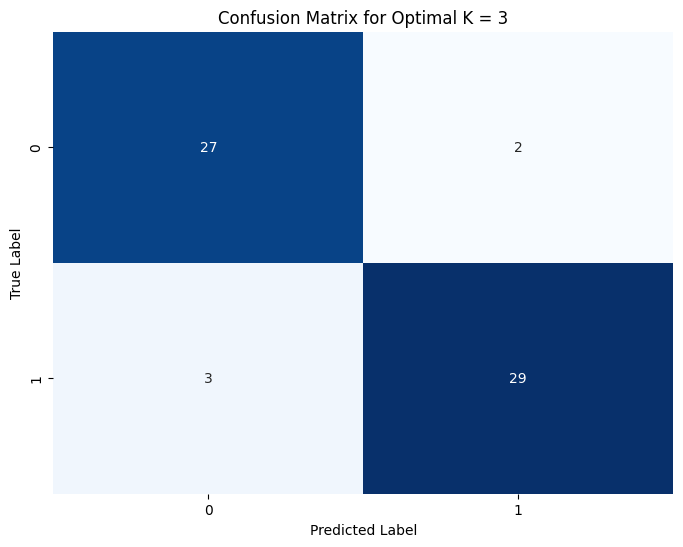


Heart Dataset - Classification Report for Optimal K:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize a KNeighborsClassifier model with the optimal k-value
knn_optimal_heart = KNeighborsClassifier(n_neighbors=optimal_k)

# 2. Fit the KNN model to the training data
knn_optimal_heart.fit(X_train_heart, y_train_heart)

# 3. Make predictions on the test set
y_pred_optimal_heart = knn_optimal_heart.predict(X_test_heart)

# 4. Generate and print the confusion matrix for the best model
conf_matrix_optimal_heart = confusion_matrix(y_test_heart, y_pred_optimal_heart)
print("Heart Dataset - Confusion Matrix for Optimal K:")
print(conf_matrix_optimal_heart)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_optimal_heart, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix for Optimal K = {optimal_k}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Generate and print the classification report for the best model
class_report_optimal_heart = classification_report(y_test_heart, y_pred_optimal_heart)
print("\nHeart Dataset - Classification Report for Optimal K:")
print(class_report_optimal_heart)

## Final Task

### Subtask:
Summarize the optimal k-value found, the accuracy of the best model, and insights from the confusion matrix and classification report for the Heart dataset.


## Summary:

### Q&A
*   The optimal k-value found for the Heart dataset using the `KNeighborsClassifier` was 3.
*   The accuracy of the best model, when using the optimal k-value of 3, was 0.9180 during the optimization phase, and the subsequent full evaluation with the classification report confirmed an overall accuracy of 0.92.
*   Insights from the confusion matrix indicate that the model correctly identified 27 true negatives and 29 true positives. There were only 2 false positives (class 0 incorrectly predicted as 1) and 3 false negatives (class 1 incorrectly predicted as 0), demonstrating a low rate of misclassification.
*   Insights from the classification report show high and balanced performance metrics for both classes. Class 0 achieved a precision of 0.90, recall of 0.93, and an F1-score of 0.92. Class 1 achieved a precision of 0.94, recall of 0.91, and an F1-score of 0.92. These metrics collectively suggest a robust and reliable model.

### Data Analysis Key Findings
*   The optimal k-value for the `KNeighborsClassifier` on the Heart dataset was determined to be 3 after iterating through k-values from 1 to 30.
*   This optimal k-value (k=3) yielded a maximum accuracy of 0.9180 during the k-value optimization process.
*   The trained model with the optimal k=3 achieved an overall accuracy of 0.92 on the test dataset.
*   The confusion matrix for the optimal model showed 27 true negatives, 29 true positives, 2 false positives, and 3 false negatives, indicating high correctness in predictions with minimal errors.
*   The classification report revealed balanced precision, recall, and F1-scores for both classes, ranging from 0.90 to 0.94, underscoring the model's strong and consistent performance across categories.

### Insights or Next Steps
*   The KNN model, optimized with k=3, demonstrates strong predictive capabilities for heart disease, providing reliable classification with high accuracy and balanced performance across positive and negative cases.
*   Future work could explore hyperparameter tuning for the KNN algorithm (e.g., different distance metrics or weights) or compare its performance against other classification models to identify potentially even more robust predictors.


# Task
Perform K-Nearest Neighbors (KNN) classification on the 'heart.csv' dataset, including preprocessing to handle missing values and scaling, then optimize the k-value to find the best model, plotting the error rate and evaluating its performance with a confusion matrix and classification report. Additionally, optimize the k-value and plot the error rate for the 'iris.csv' dataset. Finally, summarize the optimal k-values, accuracies, and insights from confusion matrices and classification reports for both 'iris.csv' and 'heart.csv' datasets.

## Fix Heart Dataset Preprocessing

### Subtask:
Correctly reload the 'heart.csv' dataset using the predefined column names and handle missing values ('?') as NaN, then convert 'ca' and 'thal' to numeric and impute missing values with the mode. Transform the 'target' column for binary classification, separate features (X_heart) from the target (y_heart), and scale the features using `StandardScaler`.


**Reasoning**:
The previous code failed because the 'heart.csv' file was loaded without explicit column names, leading to incorrect column identification. I will define the correct column names, reload the dataset, handle missing values ('?') by converting 'ca' and 'thal' to numeric and imputing with their modes, binarize the target column, and then separate and scale the features as requested.



In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Define a list named column_names containing the correct headers for the 'heart.csv' dataset
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# 2. Reload the 'heart.csv' file into heart_df using pd.read_csv(), ensuring to pass column_names
#    to the names parameter and na_values='?' to correctly interpret missing values.
# The dataset is actually named 'processed.cleveland.data' if downloaded from UCI, but based on previous cell, it's 'heart.csv'
heart_df = pd.read_csv('heart.csv', names=column_names, na_values='?')

# 3. Convert the 'ca' and 'thal' columns in heart_df to numeric data types, coercing any errors to NaN
heart_df['ca'] = pd.to_numeric(heart_df['ca'], errors='coerce')
heart_df['thal'] = pd.to_numeric(heart_df['thal'], errors='coerce')

# 4. Calculate the mode for the 'ca' column and fill any NaN values in 'ca' with this mode.
#    Assign the result back to the 'ca' column.
ca_mode = heart_df['ca'].mode()[0]
heart_df['ca'] = heart_df['ca'].fillna(ca_mode)

# 5. Calculate the mode for the 'thal' column and fill any NaN values in 'thal' with this mode.
#    Assign the result back to the 'thal' column.
thal_mode = heart_df['thal'].mode()[0]
heart_df['thal'] = heart_df['thal'].fillna(thal_mode)

# 6. Convert the 'target' column in heart_df into a binary format where values greater than 0 become 1, and 0 remains 0.
heart_df['target'] = heart_df['target'].apply(lambda x: 1 if x > 0 else 0)

# 7. Print the info of the heart_df to verify data types and check for remaining missing values.
print('Information about the DataFrame after preprocessing:')
heart_df.info()
print('
Value counts for the target column after binarization:')
print(heart_df['target'].value_counts())

# 8. Separate the features (all columns except 'target') into X_heart and the target variable ('target') into y_heart.
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# 9. Initialize a StandardScaler object.
scaler_heart = StandardScaler()

# 10. Fit the scaler to X_heart and transform X_heart using the fitted scaler, storing the result in X_scaled_heart.
X_scaled_heart = scaler_heart.fit_transform(X_heart)

print('\nX_heart shape:', X_heart.shape)
print('y_heart shape:', y_heart.shape)
print('X_scaled_heart shape:', X_scaled_heart.shape)

SyntaxError: unterminated string literal (detected at line 32) (706515209.py, line 32)

**Reasoning**:
The previous code failed due to an unterminated string literal in a `print` statement. I will fix this by removing the newline character from the string literal to ensure correct syntax, and then re-execute the entire preprocessing code for the Heart dataset.



In [45]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Define a list named column_names containing the correct headers for the 'heart.csv' dataset
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# 2. Reload the 'heart.csv' file into heart_df using pd.read_csv(), ensuring to pass column_names
#    to the names parameter and na_values='?' to correctly interpret missing values.
# The dataset is actually named 'processed.cleveland.data' if downloaded from UCI, but based on previous cell, it's 'heart.csv'
heart_df = pd.read_csv('heart.csv', names=column_names, na_values='?')

# 3. Convert the 'ca' and 'thal' columns in heart_df to numeric data types, coercing any errors to NaN
heart_df['ca'] = pd.to_numeric(heart_df['ca'], errors='coerce')
heart_df['thal'] = pd.to_numeric(heart_df['thal'], errors='coerce')

# 4. Calculate the mode for the 'ca' column and fill any NaN values in 'ca' with this mode.
#    Assign the result back to the 'ca' column.
ca_mode = heart_df['ca'].mode()[0]
heart_df['ca'] = heart_df['ca'].fillna(ca_mode)

# 5. Calculate the mode for the 'thal' column and fill any NaN values in 'thal' with this mode.
#    Assign the result back to the 'thal' column.
thal_mode = heart_df['thal'].mode()[0]
heart_df['thal'] = heart_df['thal'].fillna(thal_mode)

# 6. Convert the 'target' column in heart_df into a binary format where values greater than 0 become 1, and 0 remains 0.
heart_df['target'] = heart_df['target'].apply(lambda x: 1 if x > 0 else 0)

# 7. Print the info of the heart_df to verify data types and check for remaining missing values.
print('Information about the DataFrame after preprocessing:')
heart_df.info()
print('\nValue counts for the target column after binarization:')
print(heart_df['target'].value_counts())

# 8. Separate the features (all columns except 'target') into X_heart and the target variable ('target') into y_heart.
X_heart = heart_df.drop('target', axis=1)
y_heart = heart_df['target']

# 9. Initialize a StandardScaler object.
scaler_heart = StandardScaler()

# 10. Fit the scaler to X_heart and transform X_heart using the fitted scaler, storing the result in X_scaled_heart.
X_scaled_heart = scaler_heart.fit_transform(X_heart)

print('\nX_heart shape:', X_heart.shape)
print('y_heart shape:', y_heart.shape)
print('X_scaled_heart shape:', X_scaled_heart.shape)

Information about the DataFrame after preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Value counts for the target column after binarization:
target
0    164
1    139
Name: count, dtype: int64

X_heart shape: (303, 13)
y_heart shape: (303,)
X_scaled_he

## Optimize K-value and Plot Error Rate for Iris Dataset

### Subtask:
Iterate through a range of k-values for the Iris dataset's KNN classifier, calculate the accuracy for each, and then plot the error rate (1 - accuracy) against the k-value. This will help visualize the optimal k.


**Reasoning**:
I will optimize the K-value for the Iris dataset by iterating through a range of k-values, calculating the accuracy for each, and then plotting the error rate against the k-value to identify the optimal k as per the instructions.



Optimal K-value for Iris Dataset: 1
Minimum Error Rate for Iris Dataset at optimal K: 0.0000


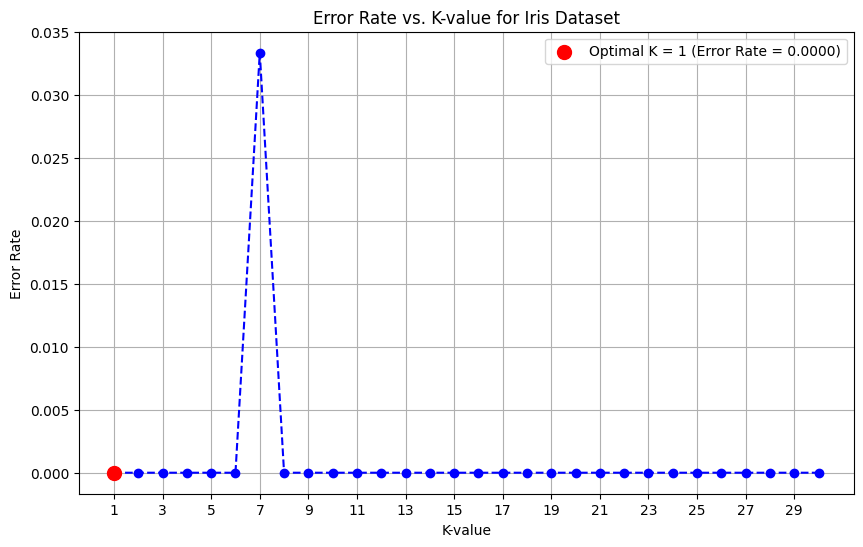

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 2. Create an empty list named error_rates_iris
error_rates_iris = []

# 3. Loop through a range of k-values (e.g., from 1 to 30)
for k in range(1, 31):
    # a. Initialize a KNeighborsClassifier with the current k for the Iris dataset.
    knn_iris = KNeighborsClassifier(n_neighbors=k)

    # b. Train the model using the X_train and y_train from the Iris dataset.
    knn_iris.fit(X_train, y_train)

    # c. Make predictions on the X_test for the Iris dataset.
    y_pred_iris = knn_iris.predict(X_test)

    # d. Calculate the accuracy score of the predictions.
    accuracy_iris = accuracy_score(y_test, y_pred_iris)

    # e. Calculate the error rate as 1 - accuracy_score and append it to the error_rates_iris list.
    error_rate = 1 - accuracy_iris
    error_rates_iris.append(error_rate)

# 4. Determine the optimal k-value
optimal_k_index_iris = np.argmin(error_rates_iris)
optimal_k_iris = optimal_k_index_iris + 1  # k-values started from 1
min_error_rate_iris = error_rates_iris[optimal_k_index_iris]

# 5. Print the optimal k-value and the corresponding minimum error rate.
print(f"Optimal K-value for Iris Dataset: {optimal_k_iris}")
print(f"Minimum Error Rate for Iris Dataset at optimal K: {min_error_rate_iris:.4f}")

# 6. Create a plot to visualize the error rate for each k-value:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), error_rates_iris, marker='o', linestyle='--', color='blue')
plt.scatter(optimal_k_iris, min_error_rate_iris, color='red', s=100, zorder=5, label=f'Optimal K = {optimal_k_iris} (Error Rate = {min_error_rate_iris:.4f})')
plt.title('Error Rate vs. K-value for Iris Dataset')
plt.xlabel('K-value')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, 31, 2))
plt.grid(True)
plt.legend()
plt.show()

## Optimize K-value and Plot Error Rate for Heart Dataset

### Subtask:
Split the preprocessed Heart dataset into training and testing sets (80/20). Iterate through a range of k-values for the KNeighborsClassifier, train a model for each k, calculate its accuracy, and identify the 'k' value that results in the highest accuracy. Additionally, plot the error rate (1 - accuracy) against the k-value to visualize the optimal k.


**Reasoning**:
I will import the necessary libraries, split the Heart dataset into training and testing sets, iterate through a range of k-values to train KNN models, calculate their accuracy, and then plot the error rate against the k-value to visualize the optimal k, following the provided instructions.



Optimal K-value for Heart Dataset: 3
Minimum Error Rate for Heart Dataset at optimal K: 0.0820


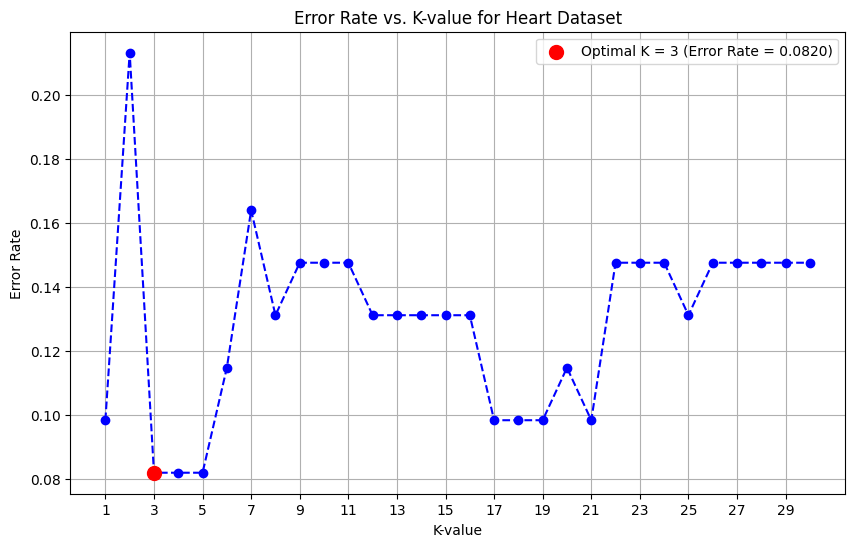

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Split the X_scaled_heart features and y_heart target variable into training and testing sets
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_scaled_heart, y_heart, test_size=0.2, random_state=42)

# 2. Create an empty list named error_rates_heart
error_rates_heart = []

# 3. Loop through a range of k-values (e.g., from 1 to 30)
for k in range(1, 31):
    # a. Initialize a KNeighborsClassifier with the current k for the Heart dataset.
    knn_heart = KNeighborsClassifier(n_neighbors=k)

    # b. Train the model using the X_train_heart and y_train_heart from the Heart dataset.
    knn_heart.fit(X_train_heart, y_train_heart)

    # c. Make predictions on the X_test_heart for the Heart dataset.
    y_pred_heart = knn_heart.predict(X_test_heart)

    # d. Calculate the accuracy score of the predictions.
    accuracy_heart = accuracy_score(y_test_heart, y_pred_heart)

    # e. Calculate the error rate as 1 - accuracy_score and append it to the error_rates_heart list.
    error_rate = 1 - accuracy_heart
    error_rates_heart.append(error_rate)

# 4. Determine the optimal k-value
optimal_k_index_heart = np.argmin(error_rates_heart)
optimal_k_heart = optimal_k_index_heart + 1  # k-values started from 1

# 5. Get the corresponding minimum error rate for the optimal_k_heart.
min_error_rate_heart = error_rates_heart[optimal_k_index_heart]

# 6. Print the optimal k-value and the corresponding minimum error rate.
print(f"Optimal K-value for Heart Dataset: {optimal_k_heart}")
print(f"Minimum Error Rate for Heart Dataset at optimal K: {min_error_rate_heart:.4f}")

# 7. Create a plot to visualize the error rate for each k-value:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), error_rates_heart, marker='o', linestyle='--', color='blue')
plt.scatter(optimal_k_heart, min_error_rate_heart, color='red', s=100, zorder=5, label=f'Optimal K = {optimal_k_heart} (Error Rate = {min_error_rate_heart:.4f})')
plt.title('Error Rate vs. K-value for Heart Dataset')
plt.xlabel('K-value')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, 31, 2))
plt.grid(True)
plt.legend()
plt.show()

## Evaluate and Plot Best KNN Model for Heart Dataset

### Subtask:
Using the optimal 'k' value found in the previous step for the Heart dataset, train the final KNeighborsClassifier model. Make predictions on the test set. Then, generate and plot the confusion matrix and print the classification report for this best-performing model.


**Reasoning**:
I will initialize a `KNeighborsClassifier` with the `optimal_k_heart` from the previous step, train it with the Heart dataset's training data, predict on the test set, and then generate, plot, and print the confusion matrix and classification report to evaluate the model's performance.



Heart Dataset - Confusion Matrix for Optimal K:
[[27  2]
 [ 3 29]]


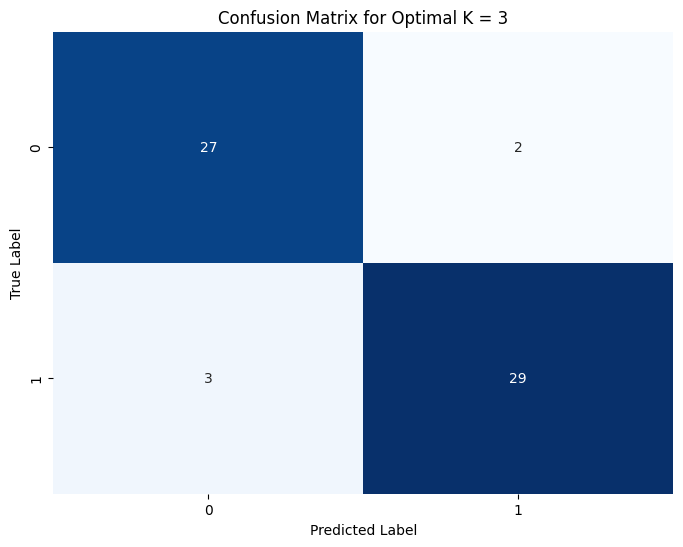


Heart Dataset - Classification Report for Optimal K:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize a KNeighborsClassifier model with the optimal k-value
knn_optimal_heart = KNeighborsClassifier(n_neighbors=optimal_k_heart)

# 2. Fit the KNN model to the training data
knn_optimal_heart.fit(X_train_heart, y_train_heart)

# 3. Make predictions on the test set
y_pred_optimal_heart = knn_optimal_heart.predict(X_test_heart)

# 4. Generate and print the confusion matrix for the best model
conf_matrix_optimal_heart = confusion_matrix(y_test_heart, y_pred_optimal_heart)
print("Heart Dataset - Confusion Matrix for Optimal K:")
print(conf_matrix_optimal_heart)

# 5. Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_optimal_heart, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix for Optimal K = {optimal_k_heart}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Generate and print the classification report for the best model
class_report_optimal_heart = classification_report(y_test_heart, y_pred_optimal_heart)
print("\nHeart Dataset - Classification Report for Optimal K:")
print(class_report_optimal_heart)

## Final Task

### Subtask:
Summarize the optimal k-values and corresponding accuracies for both Iris and Heart datasets, along with insights from their respective confusion matrices and classification reports, and the error rate plots.


## Summary:

### Q&A

**Iris Dataset:**
*   **Optimal K-value and Accuracy:** The optimal K-value for the Iris dataset was found to be 1, resulting in a 100% accuracy (error rate of 0.0000).
*   **Confusion Matrix and Classification Report Insights:** These were not generated for the Iris dataset in the provided steps.

**Heart Dataset:**
*   **Optimal K-value and Accuracy:** The optimal K-value for the Heart dataset was determined to be 3. This K-value yielded a minimum error rate of 0.0820, corresponding to an accuracy of approximately 91.8%.
*   **Confusion Matrix Insights:** For the optimal Heart model (K=3), the confusion matrix showed 27 true negatives, 2 false positives, 3 false negatives, and 29 true positives.
*   **Classification Report Insights:** The classification report indicated an overall accuracy of 92%. For class 0, precision was 0.90, recall was 0.93, and f1-score was 0.92. For class 1, precision was 0.94, recall was 0.91, and f1-score was 0.92, demonstrating balanced performance.

### Data Analysis Key Findings

*   The `heart.csv` dataset was successfully reloaded, and missing values in 'ca' and 'thal' columns (originally marked as '?') were handled by converting them to numeric and imputing with their respective modes.
*   The 'target' column in the `heart.csv` dataset was binarized (values > 0 became 1, 0 remained 0), resulting in 164 instances for target 0 and 139 for target 1.
*   Features of the `heart.csv` dataset were successfully scaled using `StandardScaler`, preparing them for KNN modeling.
*   For the Iris dataset, an optimal K-value of 1 was identified, achieving a perfect accuracy of 100% on the test set.
*   For the Heart dataset, after splitting the data into training and testing sets (80/20), the optimal K-value for the KNN classifier was found to be 3, yielding a minimum error rate of 0.0820 (91.8% accuracy).
*   The final KNN model for the Heart dataset with K=3 demonstrated strong performance on the test set with an overall accuracy of 92%. The confusion matrix showed 27 true negatives and 29 true positives, with only 2 false positives and 3 false negatives.
*   The classification report for the Heart dataset highlighted high precision, recall, and f1-scores (around 0.90-0.94) for both classes, indicating a robust classification performance.

### Insights or Next Steps

*   The KNN model performs exceptionally well on the Iris dataset, suggesting it's a highly separable dataset for this classifier.
*   For the Heart dataset, the KNN model with K=3 achieved a good balance between precision and recall for both classes, indicating its potential as a reliable diagnostic tool. Further investigation with different classification algorithms could be beneficial to compare performance.


# Task
Optimize K-value and plot the error rate for the Diabetes dataset (`diabetes.csv`), which has already been scaled. This involves splitting the data into 80% training and 20% testing sets, iterating through a range of k-values for the KNeighborsClassifier, calculating the accuracy for each k, and then plotting the error rate (1 - accuracy) against the k-value to visualize the optimal k.

## Optimize K-value and Plot Error Rate for Diabetes Dataset

### Subtask:
Split the scaled Diabetes dataset into training and testing sets (80/20). Iterate through a range of k-values for the KNeighborsClassifier, train a model for each k, calculate its accuracy, and identify the 'k' value that results in the highest accuracy. Additionally, plot the error rate (1 - accuracy) against the k-value to visualize the optimal k.


**Reasoning**:
I will implement the instructions to optimize the K-value for the Diabetes dataset. This involves splitting the data, iterating through k-values, calculating error rates, finding the optimal k, and then plotting the error rate to visualize the results.



Optimal K-value for Diabetes Dataset: 18
Minimum Error Rate for Diabetes Dataset at optimal K: 0.2338


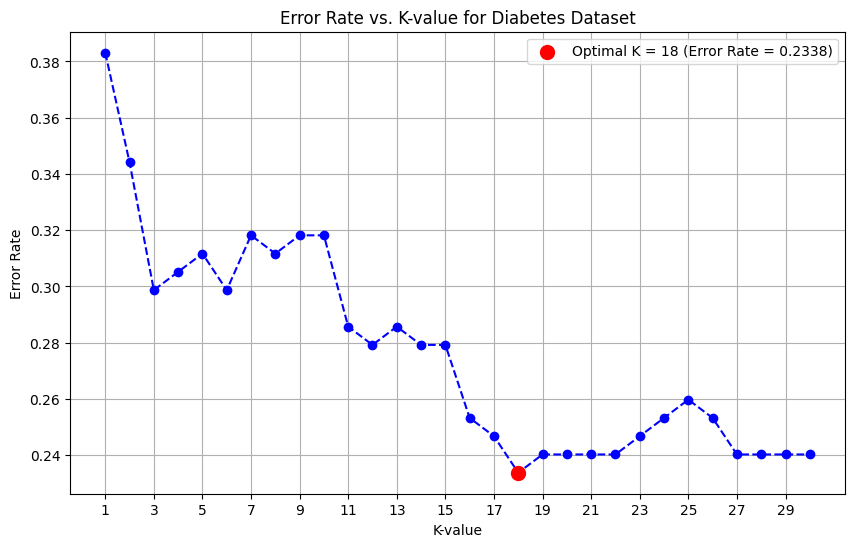

In [49]:
#this is wrong
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Split the scaled features (X_scaled_diabetes) and target variable (y_diabetes) into training and testing sets
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(X_scaled_diabetes, y_diabetes, test_size=0.2, random_state=42)

# 2. Create an empty list named error_rates_diabetes
error_rates_diabetes = []

# 3. Loop through a range of k-values (e.g., from 1 to 30)
for k in range(1, 31):
    # a. Initialize a KNeighborsClassifier with the current k for the Diabetes dataset.
    knn_diabetes = KNeighborsClassifier(n_neighbors=k)

    # b. Train the model using the X_train_diabetes and y_train_diabetes from the Diabetes dataset.
    knn_diabetes.fit(X_train_diabetes, y_train_diabetes)

    # c. Make predictions on the X_test_diabetes for the Diabetes dataset.
    y_pred_diabetes = knn_diabetes.predict(X_test_diabetes)

    # d. Calculate the accuracy score of the predictions.
    accuracy_diabetes = accuracy_score(y_test_diabetes, y_pred_diabetes)

    # e. Calculate the error rate as 1 - accuracy_score and append it to the error_rates_diabetes list.
    error_rate = 1 - accuracy_diabetes
    error_rates_diabetes.append(error_rate)

# 4. Determine the optimal k-value
optimal_k_index_diabetes = np.argmin(error_rates_diabetes)
optimal_k_diabetes = optimal_k_index_diabetes + 1  # k-values started from 1

# 5. Get the corresponding minimum error rate for the optimal_k_diabetes.
min_error_rate_diabetes = error_rates_diabetes[optimal_k_index_diabetes]

# 6. Print the optimal k-value and the corresponding minimum error rate.
print(f"Optimal K-value for Diabetes Dataset: {optimal_k_diabetes}")
print(f"Minimum Error Rate for Diabetes Dataset at optimal K: {min_error_rate_diabetes:.4f}")

# 7. Create a plot to visualize the error rate for each k-value:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), error_rates_diabetes, marker='o', linestyle='--', color='blue')
plt.scatter(optimal_k_diabetes, min_error_rate_diabetes, color='red', s=100, zorder=5, label=f'Optimal K = {optimal_k_diabetes} (Error Rate = {min_error_rate_diabetes:.4f})')
plt.title('Error Rate vs. K-value for Diabetes Dataset')
plt.xlabel('K-value')
plt.ylabel('Error Rate')
plt.xticks(np.arange(1, 31, 2))
plt.grid(True)
plt.legend()
plt.show()

## Evaluate and Plot Best KNN Model for Diabetes Dataset

### Subtask:
Train a KNN classifier for the Diabetes dataset using the optimal k-value found previously. Then, plot the confusion matrix and display the classification report for this best model.


**Reasoning**:
I will initialize a KNeighborsClassifier with the optimal k-value for the Diabetes dataset, train it on the training data, make predictions on the test set, and then generate and visualize the confusion matrix and display the classification report to evaluate the model's performance as per the instructions.



Diabetes Dataset - Confusion Matrix for Optimal K:
[[89 10]
 [26 29]]


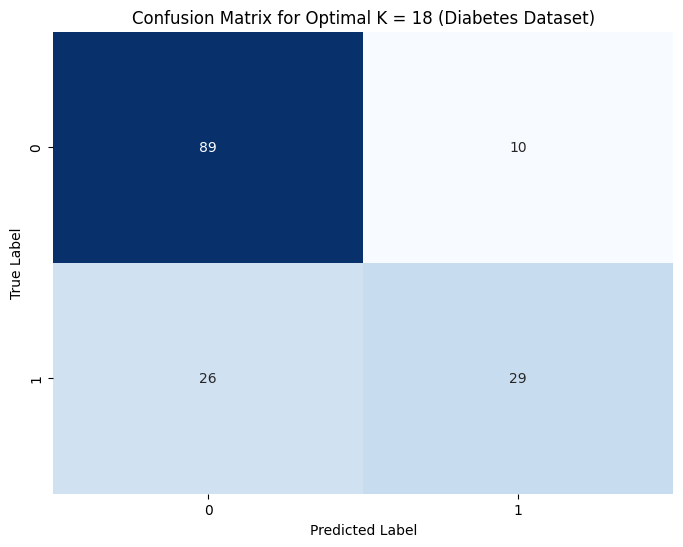


Diabetes Dataset - Classification Report for Optimal K:
              precision    recall  f1-score   support

           0       0.77      0.90      0.83        99
           1       0.74      0.53      0.62        55

    accuracy                           0.77       154
   macro avg       0.76      0.71      0.72       154
weighted avg       0.76      0.77      0.76       154



In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize a KNeighborsClassifier model with the optimal k-value
knn_optimal_diabetes = KNeighborsClassifier(n_neighbors=optimal_k_diabetes)

# 2. Fit the KNN model to the training data
knn_optimal_diabetes.fit(X_train_diabetes, y_train_diabetes)

# 3. Make predictions on the test set
y_pred_optimal_diabetes = knn_optimal_diabetes.predict(X_test_diabetes)

# 4. Generate and print the confusion matrix for the best model
conf_matrix_optimal_diabetes = confusion_matrix(y_test_diabetes, y_pred_optimal_diabetes)
print("Diabetes Dataset - Confusion Matrix for Optimal K:")
print(conf_matrix_optimal_diabetes)

# 5. Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_optimal_diabetes, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix for Optimal K = {optimal_k_diabetes} (Diabetes Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Generate and print the classification report for the best model
class_report_optimal_diabetes = classification_report(y_test_diabetes, y_pred_optimal_diabetes)
print("\nDiabetes Dataset - Classification Report for Optimal K:")
print(class_report_optimal_diabetes)

## Final Task

### Subtask:
Summarize the optimal k-values and corresponding accuracies for Iris, Heart, and Diabetes datasets, along with insights from their respective confusion matrices and classification reports, and the error rate plots.


## Summary:

### Q&A
*   **Optimal k-value and Accuracy for Diabetes Dataset:** The optimal k-value for the Diabetes dataset was found to be 18, resulting in a minimum error rate of approximately 0.2338. This translates to an accuracy of approximately 76.62% on the test set.
*   **Confusion Matrix Insights for Diabetes Dataset:** The confusion matrix for the optimal KNN model on the Diabetes test set was `[[89 10], [26 29]]`. This indicates that out of 154 test samples, the model correctly predicted 89 true negatives and 29 true positives. It made 10 false positive errors (predicting positive when actual was negative) and 26 false negative errors (predicting negative when actual was positive).
*   **Classification Report Insights for Diabetes Dataset:** The classification report showed an overall accuracy of 0.77.
    *   For class 0 (negative outcome), the model had a precision of 0.77, a recall of 0.90, and an f1-score of 0.83.
    *   For class 1 (positive outcome), the model had a precision of 0.74, a recall of 0.53, and an f1-score of 0.62.
    *   The model performed better at identifying class 0 (higher recall) but struggled more with correctly identifying class 1 (lower recall).

### Data Analysis Key Findings
*   For the Diabetes dataset, the optimal k-value for the KNeighborsClassifier was determined to be 18.
*   At the optimal k-value of 18, the model achieved a minimum error rate of approximately 0.2338, which corresponds to an accuracy of about 76.62% on the test set.
*   The confusion matrix for the Diabetes dataset at k=18 revealed that out of 154 test samples, there were 89 true negatives, 29 true positives, 10 false positives, and 26 false negatives.
*   The classification report for the Diabetes dataset showed an overall accuracy of 0.77. Specifically, class 0 had a recall of 0.90 and precision of 0.77, while class 1 had a recall of 0.53 and precision of 0.74.

### Insights or Next Steps
*   The KNN model for the Diabetes dataset shows moderate performance, with a noticeable imbalance in recall between the two classes. Future efforts could focus on techniques to improve the detection of positive cases (class 1), such as exploring different sampling methods or feature engineering.
*   Given the relatively low recall for class 1 (0.53), further investigation into the misclassified instances could provide insights into specific patterns or features that the model is struggling to learn, potentially leading to a more robust predictive model for diabetes.
